In [45]:
!pip3 install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [55]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Normalized Insertion, Deletion, and Substitution

<Axes: xlabel='model', ylabel='share'>

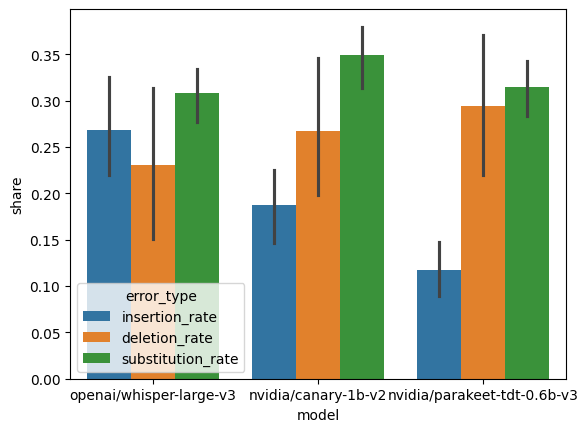

In [52]:

idf = pd.read_csv("results/evaluation_summary.csv")


idf['n_reference_words'] = (idf['substitutions'] + idf['insertions'] + idf['deletions'])/ idf['mean_wer']

# individual rates
idf['insertion_rate'] = idf['insertions']/idf['n_reference_words']
idf['deletion_rate'] = idf['deletions']/idf['n_reference_words']
idf['substitution_rate'] = idf['substitutions']/idf['n_reference_words']

df_melted = idf.melt(id_vars=['model'], value_vars=['insertion_rate','deletion_rate','substitution_rate'],
                    var_name='error_type', value_name='share')

sns.barplot(data = df_melted, x = "model", y = "share", hue='error_type')


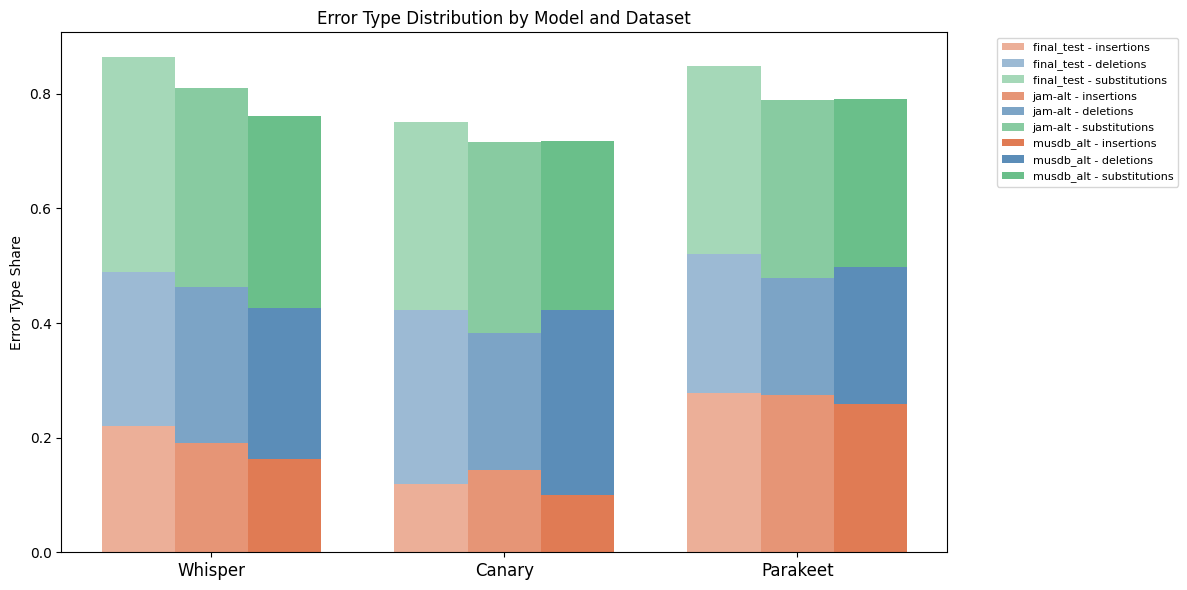

In [58]:
rdf = idf.groupby(['model', 'dataset'])[['insertion_rate', 'deletion_rate', 'substitution_rate','mean_wer']].mean()

fig, ax = plt.subplots(figsize=(12, 6))

models = rdf.index.get_level_values('model').unique()
x = np.arange(len(models))
width = 0.25
datasets = rdf.index.get_level_values('dataset').unique()

for i, dataset in enumerate(datasets):
    subset = rdf.xs(dataset, level='dataset')
    subset = subset.reindex(models)
    
    ax.bar(x + i * width, subset['insertion_rate'],  width, label=f'{dataset} - insertions',  color='#e07b54', alpha=0.6 + i*0.2)
    ax.bar(x + i * width, subset['deletion_rate'],  width, label=f'{dataset} - deletions',   color='#5b8db8', alpha=0.6 + i*0.2, bottom=subset['insertion_rate'])
    ax.bar(x + i * width, subset['substitution_rate'],  width, label=f'{dataset} - substitutions', color='#6abf8a', alpha=0.6 + i*0.2, bottom=subset['insertion_rate'] + subset['deletion_rate'])

ax.set_xticks(x + width)
ax.set_xticklabels(['Whisper', 'Canary', 'Parakeet'], fontsize=12)
ax.set_ylabel('Error Type Share')
ax.set_title('Error Type Distribution by Model and Dataset')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

